# Feature Count Analysis
Find the optimal number of features by testing models with 7 to 50+ features.

**Goal:** Identify where performance plateaus and overfitting begins.

**Method:**
1. Rank all features by correlation with target
2. Train models with top N features (N = 7, 10, 15, 20, 25, 30, 40, 50, all)
3. Compare CV accuracy vs test accuracy
4. Plot the performance curve

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score

sns.set_theme(style='whitegrid')
np.random.seed(42)

## 1. Load Full Dataset

In [2]:
# Load the full dataset with all features
df = pd.read_csv('../data/processed/tournament_matchups.csv')
print(f'Full dataset: {df.shape}')

# Get all differential columns
all_diff_cols = [c for c in df.columns if c.startswith('diff_')]
all_diff_cols.append('seed_diff')

print(f'Total differential features: {len(all_diff_cols)}')
print(f'Features: {all_diff_cols}')

Full dataset: (477, 91)
Total differential features: 28
Features: ['diff_win_pct', 'diff_srs', 'diff_sos', 'diff_ortg', 'diff_efg_pct', 'diff_tov_pct', 'diff_orb_pct', 'diff_pace', 'diff_ftr', 'diff_ts_pct', 'diff_ft_pct', 'diff_pts_for', 'diff_pts_against', 'diff_ast_pct', 'diff_stl_pct', 'diff_blk_pct', 'diff_trb_pct', 'diff_three_par', 'diff_ft_fga', 'diff_fg_pct', 'diff_three_pct', 'diff_three_made', 'diff_trb', 'diff_ast', 'diff_stl', 'diff_blk', 'diff_tov', 'seed_diff']


## 2. Rank Features by Correlation with Target

In [3]:
# Calculate correlation with home_win
correlations = df[all_diff_cols + ['home_win']].corr()['home_win'].drop('home_win')
correlations_abs = correlations.abs().sort_values(ascending=False)

# Ranked feature list
ranked_features = correlations_abs.index.tolist()

print('Features ranked by |correlation| with home_win:')
print('='*55)
for i, feat in enumerate(ranked_features, 1):
    corr = correlations[feat]
    sign = '+' if corr > 0 else '-'
    bar = '█' * int(abs(corr) * 40)
    print(f'{i:2d}. {feat:20s} {sign}{abs(corr):.4f}  {bar}')

Features ranked by |correlation| with home_win:
 1. diff_srs             +0.4212  ████████████████
 2. diff_pts_for         +0.4121  ████████████████
 3. diff_trb             +0.3497  █████████████
 4. diff_sos             +0.3192  ████████████
 5. seed_diff            +0.3016  ████████████
 6. diff_pts_against     +0.2862  ███████████
 7. diff_ast             +0.2657  ██████████
 8. diff_win_pct         +0.2309  █████████
 9. diff_three_made      +0.2257  █████████
10. diff_ortg            +0.1973  ███████
11. diff_blk             +0.1939  ███████
12. diff_stl             +0.1690  ██████
13. diff_tov_pct         -0.1606  ██████
14. diff_pace            -0.1269  █████
15. diff_ts_pct          +0.1177  ████
16. diff_tov             +0.1132  ████
17. diff_ft_pct          +0.1117  ████
18. diff_fg_pct          +0.1096  ████
19. diff_efg_pct         +0.1094  ████
20. diff_three_pct       +0.0991  ███
21. diff_blk_pct         +0.0774  ███
22. diff_ftr             -0.0653  ██
23. diff_trb_pc

## 3. Prepare Train/Test Split

In [4]:
# Temporal split: train on 2014-2022, test on 2023-2024
train_mask = df['season'] <= 2022
test_mask = df['season'] >= 2023

df_train = df[train_mask]
df_test = df[test_mask]

y_train = df_train['home_win'].values
y_test = df_test['home_win'].values

print(f'Training: {len(y_train)} games (2014-2022)')
print(f'Test: {len(y_test)} games (2023-2024)')

Training: 388 games (2014-2022)
Test: 89 games (2023-2024)


## 4. Test Different Feature Counts

In [5]:
# Feature counts to test
feature_counts = [5, 7, 10, 12, 15, 18, 20, 23, 25, 27, len(ranked_features)]

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for n_features in feature_counts:
    # Select top N features
    selected_features = ranked_features[:n_features]
    
    # Prepare data
    X_train = df_train[selected_features].values
    X_test = df_test[selected_features].values
    
    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train model
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    # Cross-validation accuracy
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # Test accuracy
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    test_acc = accuracy_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_prob)
    
    # Training accuracy (to detect overfitting)
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    
    results.append({
        'n_features': n_features,
        'train_acc': train_acc,
        'cv_acc': cv_mean,
        'cv_std': cv_std,
        'test_acc': test_acc,
        'test_auc': test_auc,
        'overfit_gap': train_acc - test_acc,
        'features': selected_features
    })
    
    print(f'N={n_features:2d}: Train={train_acc:.3f}, CV={cv_mean:.3f}±{cv_std:.3f}, Test={test_acc:.3f}, AUC={test_auc:.3f}, Gap={train_acc-test_acc:.3f}')

results_df = pd.DataFrame(results)

N= 5: Train=0.768, CV=0.755±0.019, Test=0.742, AUC=0.802, Gap=0.026
N= 7: Train=0.784, CV=0.771±0.038, Test=0.764, AUC=0.802, Gap=0.019
N=10: Train=0.814, CV=0.814±0.024, Test=0.708, AUC=0.827, Gap=0.107
N=12: Train=0.822, CV=0.812±0.030, Test=0.708, AUC=0.827, Gap=0.114


N=15: Train=0.832, CV=0.840±0.035, Test=0.764, AUC=0.857, Gap=0.068


N=18: Train=0.835, CV=0.838±0.028, Test=0.764, AUC=0.861, Gap=0.071


N=20: Train=0.835, CV=0.840±0.029, Test=0.764, AUC=0.861, Gap=0.071
N=23: Train=0.848, CV=0.840±0.024, Test=0.775, AUC=0.861, Gap=0.073
N=25: Train=0.848, CV=0.843±0.028, Test=0.775, AUC=0.860, Gap=0.073


N=27: Train=0.843, CV=0.840±0.028, Test=0.775, AUC=0.862, Gap=0.068


N=28: Train=0.843, CV=0.840±0.027, Test=0.775, AUC=0.861, Gap=0.068


## 5. Visualize Results

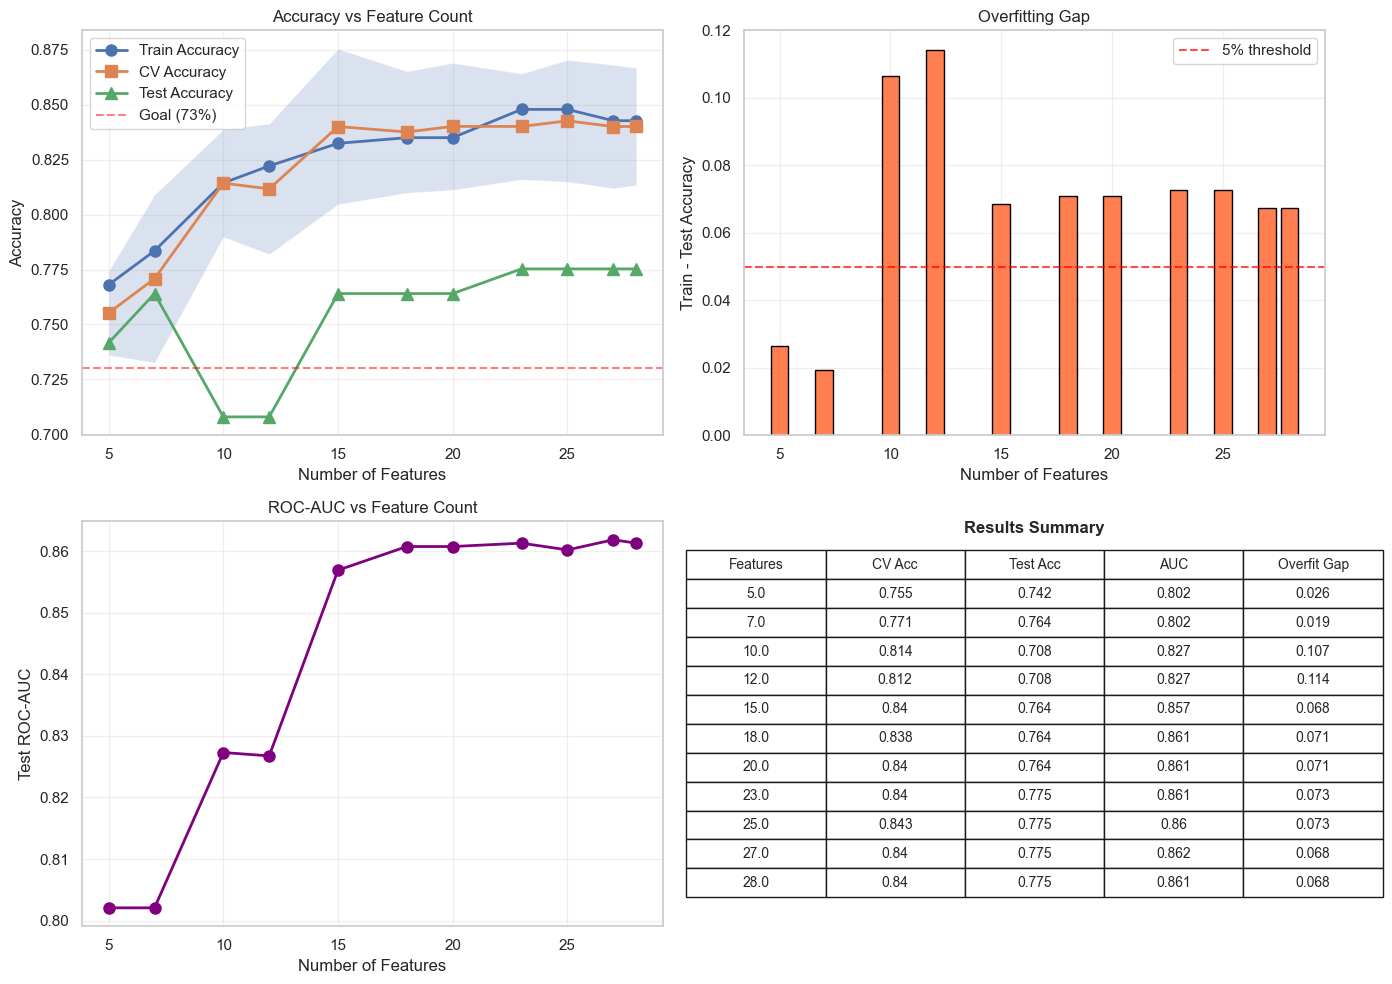

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Accuracy by feature count
ax = axes[0, 0]
ax.plot(results_df['n_features'], results_df['train_acc'], 'o-', label='Train Accuracy', linewidth=2, markersize=8)
ax.plot(results_df['n_features'], results_df['cv_acc'], 's-', label='CV Accuracy', linewidth=2, markersize=8)
ax.plot(results_df['n_features'], results_df['test_acc'], '^-', label='Test Accuracy', linewidth=2, markersize=8)
ax.fill_between(results_df['n_features'], 
                results_df['cv_acc'] - results_df['cv_std'],
                results_df['cv_acc'] + results_df['cv_std'],
                alpha=0.2)
ax.axhline(y=0.73, color='red', linestyle='--', alpha=0.5, label='Goal (73%)')
ax.set_xlabel('Number of Features')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs Feature Count')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Overfitting gap
ax = axes[0, 1]
ax.bar(results_df['n_features'], results_df['overfit_gap'], color='coral', edgecolor='black')
ax.axhline(y=0.05, color='red', linestyle='--', alpha=0.7, label='5% threshold')
ax.set_xlabel('Number of Features')
ax.set_ylabel('Train - Test Accuracy')
ax.set_title('Overfitting Gap')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: ROC-AUC by feature count
ax = axes[1, 0]
ax.plot(results_df['n_features'], results_df['test_auc'], 'o-', color='purple', linewidth=2, markersize=8)
ax.set_xlabel('Number of Features')
ax.set_ylabel('Test ROC-AUC')
ax.set_title('ROC-AUC vs Feature Count')
ax.grid(True, alpha=0.3)

# Plot 4: Summary table
ax = axes[1, 1]
ax.axis('off')
table_data = results_df[['n_features', 'cv_acc', 'test_acc', 'test_auc', 'overfit_gap']].round(3)
table_data.columns = ['Features', 'CV Acc', 'Test Acc', 'AUC', 'Overfit Gap']
table = ax.table(cellText=table_data.values,
                 colLabels=table_data.columns,
                 cellLoc='center',
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
ax.set_title('Results Summary', fontsize=12, fontweight='bold', y=0.95)

plt.tight_layout()
plt.savefig('../results/visualizations/feature_count_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Find Optimal Feature Count

In [7]:
# Find best model by test accuracy
best_by_test = results_df.loc[results_df['test_acc'].idxmax()]

# Find best model by CV accuracy
best_by_cv = results_df.loc[results_df['cv_acc'].idxmax()]

# Find best model with low overfitting (<5% gap)
low_overfit = results_df[results_df['overfit_gap'] < 0.05]
if len(low_overfit) > 0:
    best_balanced = low_overfit.loc[low_overfit['test_acc'].idxmax()]
else:
    best_balanced = results_df.loc[results_df['overfit_gap'].idxmin()]

print('='*60)
print('OPTIMAL FEATURE COUNT ANALYSIS')
print('='*60)

print(f'\nBest by TEST accuracy:')
print(f'  Features: {int(best_by_test["n_features"])}')
print(f'  Test Accuracy: {best_by_test["test_acc"]:.1%}')
print(f'  Overfit Gap: {best_by_test["overfit_gap"]:.1%}')

print(f'\nBest by CV accuracy:')
print(f'  Features: {int(best_by_cv["n_features"])}')
print(f'  CV Accuracy: {best_by_cv["cv_acc"]:.1%}')
print(f'  Test Accuracy: {best_by_cv["test_acc"]:.1%}')

print(f'\nBest balanced (low overfitting):')
print(f'  Features: {int(best_balanced["n_features"])}')
print(f'  Test Accuracy: {best_balanced["test_acc"]:.1%}')
print(f'  Overfit Gap: {best_balanced["overfit_gap"]:.1%}')

OPTIMAL FEATURE COUNT ANALYSIS

Best by TEST accuracy:
  Features: 23
  Test Accuracy: 77.5%
  Overfit Gap: 7.3%

Best by CV accuracy:
  Features: 25
  CV Accuracy: 84.3%
  Test Accuracy: 77.5%

Best balanced (low overfitting):
  Features: 7
  Test Accuracy: 76.4%
  Overfit Gap: 1.9%


In [8]:
# Show features for best model
optimal_n = int(best_by_test['n_features'])
optimal_features = ranked_features[:optimal_n]

print(f'\nOptimal feature set ({optimal_n} features):')
print('='*50)
for i, feat in enumerate(optimal_features, 1):
    corr = correlations[feat]
    print(f'  {i:2d}. {feat:20s} (r={corr:+.4f})')


Optimal feature set (23 features):
   1. diff_srs             (r=+0.4212)
   2. diff_pts_for         (r=+0.4121)
   3. diff_trb             (r=+0.3497)
   4. diff_sos             (r=+0.3192)
   5. seed_diff            (r=+0.3016)
   6. diff_pts_against     (r=+0.2862)
   7. diff_ast             (r=+0.2657)
   8. diff_win_pct         (r=+0.2309)
   9. diff_three_made      (r=+0.2257)
  10. diff_ortg            (r=+0.1973)
  11. diff_blk             (r=+0.1939)
  12. diff_stl             (r=+0.1690)
  13. diff_tov_pct         (r=-0.1606)
  14. diff_pace            (r=-0.1269)
  15. diff_ts_pct          (r=+0.1177)
  16. diff_tov             (r=+0.1132)
  17. diff_ft_pct          (r=+0.1117)
  18. diff_fg_pct          (r=+0.1096)
  19. diff_efg_pct         (r=+0.1094)
  20. diff_three_pct       (r=+0.0991)
  21. diff_blk_pct         (r=+0.0774)
  22. diff_ftr             (r=-0.0653)
  23. diff_trb_pct         (r=+0.0541)


## 7. Save Optimal Dataset

In [9]:
# Create dataset with optimal features
meta_cols = ['season', 'round', 'home_team', 'away_team', 'home_seed', 'away_seed', 
             'home_score', 'away_score', 'home_win']

df_optimal = df[meta_cols + optimal_features].copy()

# Save
output_path = Path('../data/processed/matchups_optimal.csv')
df_optimal.to_csv(output_path, index=False)

print(f'Saved optimal dataset: {df_optimal.shape}')
print(f'  Features: {optimal_n}')
print(f'  Path: {output_path}')

Saved optimal dataset: (477, 32)
  Features: 23
  Path: ..\data\processed\matchups_optimal.csv


In [10]:
# Final comparison
print('\n' + '='*60)
print('FINAL RECOMMENDATION')
print('='*60)

results_df_display = results_df[['n_features', 'train_acc', 'cv_acc', 'test_acc', 'test_auc', 'overfit_gap']].copy()
results_df_display.columns = ['Features', 'Train', 'CV', 'Test', 'AUC', 'Overfit']
results_df_display = results_df_display.round(3)

# Highlight best
print(results_df_display.to_string(index=False))

print(f'\n→ Recommended: {optimal_n} features')
print(f'  Test accuracy: {best_by_test["test_acc"]:.1%}')
print(f'  ROC-AUC: {best_by_test["test_auc"]:.3f}')


FINAL RECOMMENDATION
 Features  Train    CV  Test   AUC  Overfit
        5  0.768 0.755 0.742 0.802    0.026
        7  0.784 0.771 0.764 0.802    0.019
       10  0.814 0.814 0.708 0.827    0.107
       12  0.822 0.812 0.708 0.827    0.114
       15  0.832 0.840 0.764 0.857    0.068
       18  0.835 0.838 0.764 0.861    0.071
       20  0.835 0.840 0.764 0.861    0.071
       23  0.848 0.840 0.775 0.861    0.073
       25  0.848 0.843 0.775 0.860    0.073
       27  0.843 0.840 0.775 0.862    0.068
       28  0.843 0.840 0.775 0.861    0.068

→ Recommended: 23 features
  Test accuracy: 77.5%
  ROC-AUC: 0.861
